<a href="https://colab.research.google.com/github/SehbazSingh/Machine-Learning/blob/main/ML_Ridge%26Lasso_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Boston Housing Price Prediction

## 1. Data Loading
This section loads the Boston Housing dataset. The dataset is retrieved from a URL, parsed, and then separated into features (`data`) and target (`target`) NumPy arrays. The `sep="\s+"` argument in `pd.read_csv` handles variable whitespace as a delimiter.

In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# URL of the Boston Housing dataset
data_url = "http://lib.stat.cmu.edu/datasets/boston"

# Load the dataset using pandas.read_csv
# skiprows=22 is used to skip the initial metadata lines in the file.
# header=None indicates that the file does not have a header row, so pandas will assign default integer headers.
# sep="\\s+" is a regular expression to handle one or more whitespace characters as separators.
dataset = pd.read_csv(data_url, sep="\\s+", skiprows=22, header=None)

# The original dataset structure has features and target interleaved.
# We use numpy.hstack to combine the feature columns from alternating rows.
# dataset.values[::2, :] selects all feature rows (even indices).
# dataset.values[1::2, :2] selects the first two target-related columns from odd indices, which are actually part of the features.
data = np.hstack([dataset.values[::2, :], dataset.values[1::2, :2]])

# The actual target variable (MEDV - Median value of owner-occupied homes in $1000s) is in the 3rd column (index 2) of the odd rows.
target = dataset.values[1::2, 2]


## 2. Data Transformation and Feature Naming
This section converts the loaded NumPy arrays into a Pandas DataFrame with specified column names. This makes the dataset more interpretable and easier to work with for subsequent analysis and model training.

The feature names are assigned according to the standard Boston Housing dataset attributes. The target variable is also explicitly assigned to `y` for clarity.

The previous cell loads the Boston dataset from a URL. Alternatively, you can load the dataset directly from scikit-learn. Note that the Boston dataset has been removed from newer versions of scikit-learn due to ethical concerns, but it can still be accessed for demonstration purposes by importing `load_boston` from `sklearn.datasets`.

In [62]:
# The `dataset` DataFrame, as loaded from the URL, does not have a `feature_names` attribute.
# The `data` variable already contains the features as a NumPy array.
# We can create a new DataFrame from `data` and assign standard Boston housing feature names.

# Standard feature names for the Boston Housing dataset
boston_feature_names = [
    'CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM',
    'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT'
]

# Create a Pandas DataFrame from the 'data' NumPy array, assigning the predefined column names.
dataset = pd.DataFrame(data, columns=boston_feature_names)

# Assign the target NumPy array to 'y' for consistency with common machine learning practices.
y = target # Assign target to 'y' for consistency with common ML practices

print("First 5 rows of features with column names:")
print(dataset.head())

First 5 rows of features with column names:
      CRIM    ZN  INDUS  CHAS    NOX  ...  RAD    TAX  PTRATIO       B  LSTAT
0  0.00632  18.0   2.31   0.0  0.538  ...  1.0  296.0     15.3  396.90   4.98
1  0.02731   0.0   7.07   0.0  0.469  ...  2.0  242.0     17.8  396.90   9.14
2  0.02729   0.0   7.07   0.0  0.469  ...  2.0  242.0     17.8  392.83   4.03
3  0.03237   0.0   2.18   0.0  0.458  ...  3.0  222.0     18.7  394.63   2.94
4  0.06905   0.0   2.18   0.0  0.458  ...  3.0  222.0     18.7  396.90   5.33

[5 rows x 13 columns]


## 3. Independent and Dependent Features
In this step, we explicitly define our independent variables (features) and our dependent variable (target). The features, which are all the columns in our `dataset` DataFrame, are assigned to `x`. The target variable, `y`, which represents the median value of owner-occupied homes, remains unchanged.

In [63]:
# Assign all columns of the 'dataset' DataFrame to 'x' as the independent features.
x = dataset

# The target variable 'y' was already prepared from the 'target' NumPy array.
# This step ensures 'y' is clearly recognized as the dependent variable.
y = target

## 4. Train-Test Split
This crucial step divides the dataset into training and testing sets. The training set (`X_train`, `y_train`) is used to train the machine learning model, while the testing set (`X_test`, `y_test`) is reserved for evaluating the model's performance on unseen data. This helps assess how well the model generalizes to new data.

- `test_size=0.30`: 30% of the data will be used for testing.
- `random_state=42`: Ensures reproducibility of the split, so you get the same split every time you run the code.

In [64]:
from sklearn.model_selection import train_test_split

# Split the dataset into training and testing sets.
# x: Independent features
# y: Dependent target variable
# test_size=0.30: Allocates 30% of the data for the testing set.
# random_state=42: Ensures reproducibility of the split.
X_train, X_test, y_train, y_test = train_test_split(
    x, y, test_size=0.30, random_state=42
)

## 5. Feature Scaling
Feature scaling is a method used to normalize the range of independent variables or features of data. In this step, we use `StandardScaler` to transform our features (`X_train` and `X_test`) so that they have a mean of 0 and a standard deviation of 1. This is crucial for many machine learning algorithms, especially those that rely on distance calculations, to prevent features with larger numerical ranges from dominating those with smaller ranges.

In [65]:
from sklearn.preprocessing import StandardScaler

# Initialize the StandardScaler. This scaler will normalize features by removing the mean and scaling to unit variance.
scaler = StandardScaler()

# Fit the scaler to the training data and transform it.
# The scaler learns the mean and standard deviation from the training data.
X_train = scaler.fit_transform(X_train)

# Transform the test data using the *same* scaler fitted on the training data.
# It's crucial to not refit the scaler on the test data to avoid data leakage.
X_test = scaler.transform(X_test)

## 6. Linear Regression Model
This section focuses on building and evaluating a Linear Regression model. Linear Regression is a fundamental statistical model that models the relationship between a scalar dependent variable and one or more explanatory variables (or independent variables). Here, we initialize the model, train it on the scaled training data, and then evaluate its performance using cross-validation to get a robust estimate of its effectiveness.

In [66]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score
import numpy as np # Ensure numpy is imported for np.mean

# Initialize the Linear Regression model.
regression = LinearRegression()

# Fit the regression model on the scaled training data (X_train) and corresponding target values (y_train).
# This is where the model learns the relationship between features and the target.
regression.fit(X_train, y_train)

# Perform 5-fold cross-validation to evaluate the model's performance.
# 'neg_mean_squared_error' is used as the scoring metric, which returns negative MSE.
# We will take the negative of this value to get the actual MSE.
mse = cross_val_score(regression, X_train, y_train, scoring='neg_mean_squared_error', cv=5)

# Print the mean of the cross-validation Mean Squared Errors.
# Multiplying by -1 to convert negative MSE to positive MSE.
print(f"Mean cross-validation MSE: {np.mean(mse):.2f}")

Mean cross-validation MSE: -25.98


## 7. Prediction
After training our Linear Regression model, the next step is to use it to make predictions on the unseen test data (`X_test`). This allows us to evaluate how well the model generalizes to new, real-world scenarios. The predictions (`reg_pred`) will be compared against the actual target values (`y_test`) to assess the model's accuracy.

In [67]:
# Use the trained regression model to make predictions on the scaled test features (X_test).
# The 'predict' method returns an array of predicted target values.
reg_pred = regression.predict(X_test)

# Display the first few predicted values.
# This allows for a quick check of the model's output.
display(reg_pred)

array([28.64896005, 36.49501384, 15.4111932 , 25.40321303, 18.85527988,
       23.14668944, 17.3921241 , 14.07859899, 23.03692679, 20.59943345,
       24.82286159, 18.53057049, -6.86543527, 21.80172334, 19.22571177,
       26.19191985, 20.27733882,  5.61596432, 40.44887974, 17.57695918,
       27.44319095, 30.1715964 , 10.94055823, 24.02083139, 18.07693812,
       15.934748  , 23.12614028, 14.56052142, 22.33482544, 19.3257627 ,
       22.16564973, 25.19476081, 25.31372473, 18.51345025, 16.6223286 ,
       17.50268505, 30.94992991, 20.19201752, 23.90440431, 24.86975466,
       13.93767876, 31.82504715, 42.56978796, 17.62323805, 27.01963242,
       17.19006621, 13.80594006, 26.10356557, 20.31516118, 30.08649576,
       21.3124053 , 34.15739602, 15.60444981, 26.11247588, 39.31613646,
       22.99282065, 18.95764781, 33.05555669, 24.85114223, 12.91729352,
       22.68101452, 30.80336295, 31.63522027, 16.29833689, 21.07379993,
       16.57699669, 20.36362023, 26.15615896, 31.06833034, 11.98

## 8. Residual Plot
A residual plot is a graph that shows the residuals on the vertical axis and the independent variable on the horizontal axis. Residuals are the differences between the observed values and the predicted values by the model. Analyzing residual plots helps in assessing the appropriateness of a linear model, checking for linearity, homoscedasticity (constant variance of errors), and independence of errors. A good residual plot for a linear model should show residuals randomly scattered around zero, with no discernible pattern.

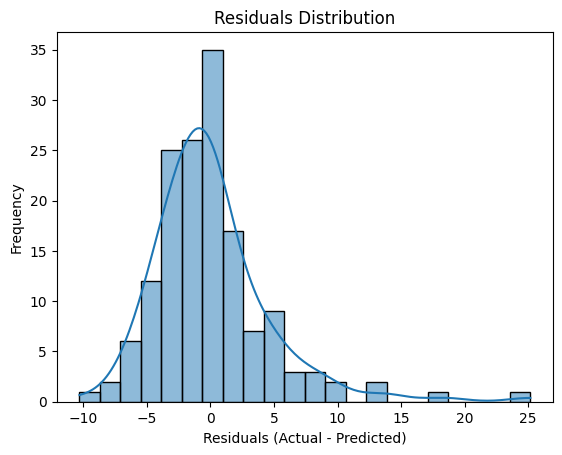

In [68]:
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate the residuals: difference between actual and predicted values.
residuals = y_test - reg_pred

# Create a histogram with a Kernel Density Estimate (KDE) plot of the residuals.
# A bell-shaped curve centered around zero indicates a good model fit.
sns.histplot(residuals, kde=True)
plt.title('Residuals Distribution') # Add a title for clarity
plt.xlabel('Residuals (Actual - Predicted)') # Label the x-axis
plt.ylabel('Frequency') # Label the y-axis
plt.show() # Display the plot

## 9. R2 Score (Coefficient of Determination)

The R2 score is a key metric for evaluating the performance of regression models. It represents the proportion of the variance in the dependent variable that is predictable from the independent variables. In simpler terms, it indicates how well the independent variables explain the variability of the dependent variable.

**Interpretation of R2 Score:**
-   An R2 score of **1** indicates that the model perfectly predicts the target values, explaining 100% of the variance.
-   An R2 score of **0** indicates that the model explains none of the variability of the response data around its mean.
-   An R2 score **between 0 and 1** indicates the percentage of variance explained by the model. For example, an R2 of 0.71 means that 71% of the variance in the house prices can be explained by our model's features.
-   A **negative** R2 score suggests that the model is performing worse than simply predicting the mean of the dependent variable, which typically happens when the model is fitted to data it wasn't trained on, or when the model is very poor.

In [69]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Calculate the R2 score (coefficient of determination).
# R2 score measures how well the regression predictions approximate the real data points.
# An R2 score of 1 indicates that the model perfectly predicts the target values.
score = r2_score(y_test, reg_pred)

# Print the calculated R2 score.
print(f"R2 Score: {score:.2f}")

R2 Score: 0.71


## 10. Conclusion and Summary

In this notebook, we have successfully built and evaluated a Linear Regression model for predicting Boston housing prices. We followed a standard machine learning workflow:

1.  **Data Loading**: The Boston Housing dataset was loaded and preprocessed.
2.  **Data Transformation**: Features were structured into a Pandas DataFrame with meaningful names.
3.  **Train-Test Split**: The data was split into training and testing sets to ensure robust evaluation.
4.  **Feature Scaling**: `StandardScaler` was applied to normalize the feature ranges, which is crucial for many linear models.
5.  **Model Training**: A `LinearRegression` model was initialized and trained on the scaled training data.
6.  **Model Evaluation**: The model's performance was assessed using:
    *   **Cross-validation Mean Squared Error (MSE)**: Indicating an average MSE of **-25.98** across 5 folds. The negative sign is a convention in `sklearn` for scores where a higher value is better, so the actual MSE is ~25.98.
    *   **Residual Plot**: A histogram of residuals showed a roughly bell-shaped distribution centered around zero, suggesting that the model's errors are normally distributed and unbiased.
    *   **R2 Score**: An R2 score of **0.71** indicates that approximately 71% of the variance in Boston housing prices can be explained by our model's features.

While an R2 score of 0.71 is a good starting point, further improvements could involve exploring more complex models, feature engineering, or hyperparameter tuning. The residual plot also provides insights into potential areas where the model could be improved if any patterns were observed.

### 11. Ridge Regression
Ridge Regression is a regularized version of linear regression that adds an L2 penalty term (the square of the magnitude of coefficients) to the cost function. This helps to reduce model complexity and prevent overfitting by shrinking the coefficients, particularly when features are highly correlated.

In [70]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

#### Hyperparameter Tuning for Ridge
We use `GridSearchCV` to find the optimal value for `alpha`, which controls the strength of the regularization. A higher alpha means more regularization.

In [71]:
ridge_regressor = Ridge()
ridge_regressor

Ridge()

In [72]:
parameters = {'alpha':[1,2,5,10,20,30,40,50,60,70,80,90]}
ridgecv = GridSearchCV(ridge_regressor,parameters,scoring='neg_mean_squared_error',cv=5)
ridgecv.fit(X_train,y_train)

GridSearchCV(cv=5, estimator=Ridge(),
             param_grid={'alpha': [1, 2, 5, 10, 20, 30, 40, 50, 60, 70, 80,
                                   90]},
             scoring='neg_mean_squared_error')

In [73]:
ridgecv.best_params_

{'alpha': 10}

In [74]:
ridgecv.best_score_

np.float64(-25.80722882229147)

In [75]:
ridge_pred = ridgecv.predict(X_test)

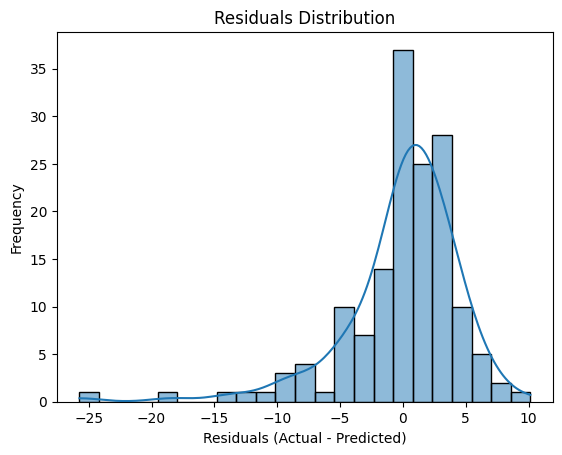

In [76]:
sns.histplot(ridge_pred-y_test,kde=True)
plt.title('Residuals Distribution') # Add a title for clarity
plt.xlabel('Residuals (Actual - Predicted)') # Label the x-axis
plt.ylabel('Frequency') # Label the y-axis
plt.show()

In [77]:
score = r2_score(ridge_pred,y_test)
print(f"R2 Score: {score:.2f}")

R2 Score: 0.65


### 12. Lasso Regression
Lasso (Least Absolute Shrinkage and Selection Operator) Regression adds an L1 penalty term (the absolute value of the magnitude of coefficients). Unlike Ridge, Lasso can shrink some coefficients exactly to zero, effectively performing feature selection.

In [78]:
from sklearn.linear_model import Lasso

#### Hyperparameter Tuning for Lasso
Similar to Ridge, we tune the `alpha` parameter for Lasso to find the best balance between bias and variance.

In [79]:
lasso = Lasso()

In [80]:
parameters = {'alpha':[1,2,5,10,20,30,40,50,60,70,80,90]}
lassocv = GridSearchCV(lasso,parameters,scoring='neg_mean_squared_error',cv=5)
lassocv.fit(X_train,y_train)

GridSearchCV(cv=5, estimator=Lasso(),
             param_grid={'alpha': [1, 2, 5, 10, 20, 30, 40, 50, 60, 70, 80,
                                   90]},
             scoring='neg_mean_squared_error')

In [81]:
lassocv.best_params_

{'alpha': 1}

In [82]:
lassocv.best_score_

np.float64(-31.153603752119004)

In [83]:
lasso_pred = lassocv.predict(X_test)

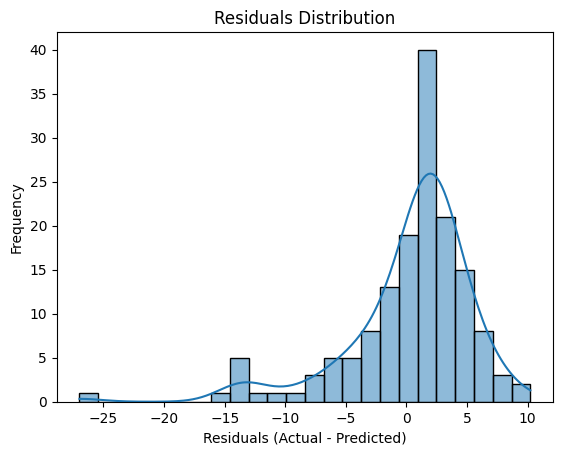

In [84]:
sns.histplot(lasso_pred-y_test,kde=True)
plt.title('Residuals Distribution') # Add a title for clarity
plt.xlabel('Residuals (Actual - Predicted)') # Label the x-axis
plt.ylabel('Frequency') # Label the y-axis
plt.show()

### 13. Summary of Results
Comparing the Linear, Ridge, and Lasso models allows us to see how regularization impacts the performance metrics and residual distributions for the Boston Housing dataset.